In [1]:
import pandas as pd
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
emails = [
    ("Congratulations! You won a free iPhone. Click here.", "Spam"),
    ("Meeting scheduled tomorrow at 10 AM.", "Ham"),
    ("Limited time offer! Buy now and save 80%.", "Spam"),
    ("Project report has been approved.", "Ham"),
    ("Win cash prizes by participating today.", "Spam"),
    ("Please review the attached document.", "Ham"),
    ("Claim your reward immediately.", "Spam"),
    ("Your order has been shipped successfully.", "Ham"),
    ("Exclusive deal only for you.", "Spam"),
    ("Let's have lunch tomorrow.", "Ham"),
    ("You have received a lottery prize.", "Spam"),
    ("Monthly salary has been credited.", "Ham"),
    ("Cheap medicines available online.", "Spam"),
    ("Can we reschedule the meeting?", "Ham"),
    ("Urgent! Verify your bank account now.", "Spam"),
    ("Happy Birthday! Have a wonderful day.", "Ham"),
    ("Earn money quickly from home.", "Spam"),
    ("Invoice for your recent purchase attached.", "Ham"),
    ("Congratulations! Claim your bonus now.", "Spam"),
    ("Team meeting postponed to Friday.", "Ham")
]

In [5]:
df = pd.DataFrame(emails, columns=["Email", "Label"])

print("Original Dataset")
print(df)

Original Dataset
                                                Email Label
0   Congratulations! You won a free iPhone. Click ...  Spam
1                Meeting scheduled tomorrow at 10 AM.   Ham
2           Limited time offer! Buy now and save 80%.  Spam
3                   Project report has been approved.   Ham
4             Win cash prizes by participating today.  Spam
5                Please review the attached document.   Ham
6                      Claim your reward immediately.  Spam
7           Your order has been shipped successfully.   Ham
8                        Exclusive deal only for you.  Spam
9                          Let's have lunch tomorrow.   Ham
10                 You have received a lottery prize.  Spam
11                  Monthly salary has been credited.   Ham
12                  Cheap medicines available online.  Spam
13                     Can we reschedule the meeting?   Ham
14              Urgent! Verify your bank account now.  Spam
15              Happy B

In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

df["Clean_Email"] = df["Email"].apply(preprocess)

print("\nPreprocessed Emails")
print(df)


Preprocessed Emails
                                                Email Label  \
0   Congratulations! You won a free iPhone. Click ...  Spam   
1                Meeting scheduled tomorrow at 10 AM.   Ham   
2           Limited time offer! Buy now and save 80%.  Spam   
3                   Project report has been approved.   Ham   
4             Win cash prizes by participating today.  Spam   
5                Please review the attached document.   Ham   
6                      Claim your reward immediately.  Spam   
7           Your order has been shipped successfully.   Ham   
8                        Exclusive deal only for you.  Spam   
9                          Let's have lunch tomorrow.   Ham   
10                 You have received a lottery prize.  Spam   
11                  Monthly salary has been credited.   Ham   
12                  Cheap medicines available online.  Spam   
13                     Can we reschedule the meeting?   Ham   
14              Urgent! Verify you

In [7]:
X = df["Clean_Email"]
y = df["Label"]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)



Accuracy
50.0 %

Classification Report
              precision    recall  f1-score   support

         Ham       1.00      0.25      0.40         4
        Spam       0.40      1.00      0.57         2

    accuracy                           0.50         6
   macro avg       0.70      0.62      0.49         6
weighted avg       0.80      0.50      0.46         6


Confusion Matrix
[[1 3]
 [0 2]]


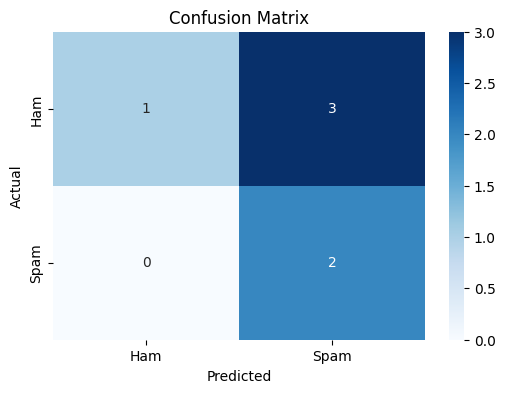

In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy")
print(round(accuracy * 100, 2), "%")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
spam_count = len(df[df["Label"] == "Spam"])
ham_count = len(df[df["Label"] == "Ham"])

print("\n========== Spam Analysis Report ==========")

print("Total Emails :", len(df))
print("Spam Emails  :", spam_count)
print("Ham Emails   :", ham_count)

print("\nSpam Percentage :",
      round((spam_count/len(df))*100,2), "%")

print("Ham Percentage  :",
      round((ham_count/len(df))*100,2), "%")

print("\nModel Accuracy :", round(accuracy*100,2), "%")



========== Spam Analysis Report ==========
Total Emails : 20
Spam Emails  : 10
Ham Emails   : 10

Spam Percentage : 50.0 %
Ham Percentage  : 50.0 %

Model Accuracy : 50.0 %


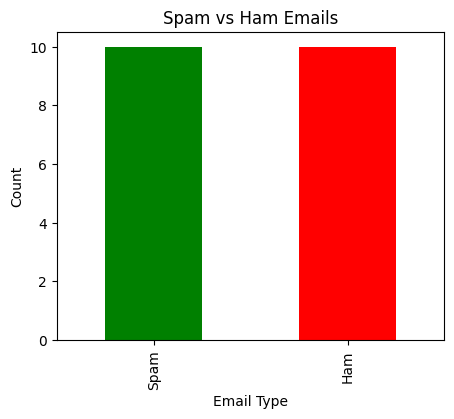

In [10]:
plt.figure(figsize=(5,4))

df["Label"].value_counts().plot(kind="bar", color=["green","red"])

plt.title("Spam vs Ham Emails")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.show()

In [11]:
print("\n========== Test Custom Email ==========")

sample = input("Enter an Email: ")

sample = preprocess(sample)

sample_vector = vectorizer.transform([sample])

prediction = model.predict(sample_vector)

print("Prediction :", prediction[0])


========== Test Custom Email ==========
Enter an Email: aathish5.9.2004@gmail.com
Prediction : Spam
